# Machine Learning Fundamentals - The Linear Regression - from Intuition to Geometry

<a href="https://www.kaggle.com/code/addarm/ml-fundamentals-the-linear-regression" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<!-- @import "[TOC]" {cmd="toc" depthFrom=1 depthTo=6 orderedList=false} -->

![Linear Regressions SORA 2.2026](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/linear_regression_banner.png)

Machine learning is everywhere today, from neural networks to transformers to agents. But if you peel away the sophistication, much of it rests on one pillar: the humble linear regression.

We return to linear models because the tool is powerful and interpretable. In this article, we will build linear regression from first principles and see how it reasons with data through an objective function, a geometric projection, and the diagnostics that tell us when the model is (and is not) trustworthy.

If you can follow the derivation once, you can re-derive it any time.

*Note*: Due to the size of the mathematical notation parts, I organized and rendered them with the help of GenAI. If you see some anomaly, its unintentional. I also recommend reading directly from the notebooks sinces its formula heavy.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from numpy.linalg import inv
from pprint import pprint

print("python", sys.version.split()[0])
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("sklearn", sklearn.__version__)


python 3.11.14
numpy 2.1.3
pandas 3.0.0
sklearn 1.8.0


# The Dataset

Every good ML story starts with data. In this one, we will use the built-in diabetes dataset provided by scikit-learn (documentation: https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset). This dataset is a standard benchmark for continuous prediction: the goal is to predict the measure of disease progression from ten covariates. Because it ships with the library, it requires no external downloads or preprocessing.

For intuition, let's begin with a single-feature view using the standardized body mass index (BMI) covariate, and visualize its relationship with disease progression - our label:

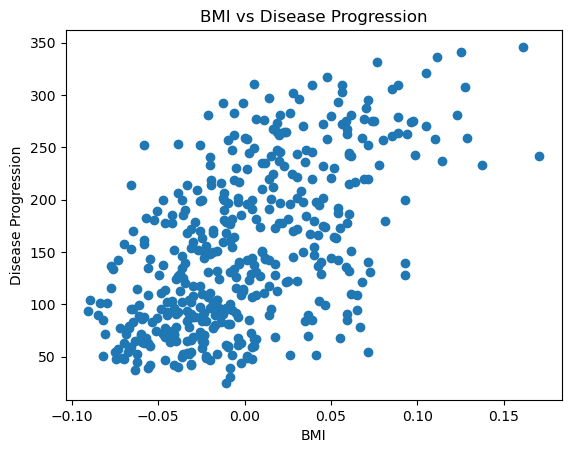

In [2]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

bmi_idx = feature_names.index("bmi")

x_bmi = X[:, bmi_idx]

plt.figure()
plt.scatter(x_bmi, y)
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("BMI vs Disease Progression")
plt.show()


# The Linear Regression Principles

Suppose we observe pairs of numbers $(x_i, y_i)$ for $i = 1, \dots, n$.  
Each $x_i$ is an input (or feature), and each $y_i$ is an output we want to predict.

In simple linear regression, we assume that $y$ is related to $x$ by a straight line:

$$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i.
$$

Here,

- $\beta_0$ is the intercept (where the line crosses the vertical axis),  
- $\beta_1$ is the slope (how steep the line is),  
- $\varepsilon_i$ represents noise or unmodeled effects.

Given values for $\beta_0$ and $\beta_1$, the model predicts

$$
\hat{y}_i = \beta_0 + \beta_1 x_i.
$$

The difference between what we observe and what we predict is called the residual:

$$
r_i = y_i - \hat{y}_i.
$$

Geometrically, the residual is the vertical distance from the data point $(x_i, y_i)$ to the line. Different choices of $\beta_0$ and $\beta_1$ give different lines, and therefore different residuals.

To decide which line is best, we need a way to measure how bad a line is overall. We do this by squaring each residual and adding them together. This gives the sum of squared errors (SSE):

$$
\text{SSE}(\beta_0,\beta_1)
= \sum_{i=1}^n \left(y_i - (\beta_0 + \beta_1 x_i)\right)^2.
$$

The goal of linear regression is to choose $\beta_0$ and $\beta_1$ that make this quantity as small as possible. Squaring ensures that large mistakes count more than small ones, avoids positives from cancelling negatives, and gives us a smooth curve to optimize.


### A Short Calculus Refresher — The Chain Rule

To minimize the sum of squared errors, we need to take derivatives of expressions like

$$
\left[y_i - (\beta_0 + \beta_1 x_i)\right]^2.
$$

This expression is a **function inside another function**.

Think of it in two steps:

First, define the inner quantity

$$
u = y_i - (\beta_0 + \beta_1 x_i).
$$

Then square it:

$$
f(u) = u^2.
$$

The chain rule tells us that when we differentiate $u^2$, we get

$$
\frac{\partial}{\partial \beta_j}(u^2)
= 2u \cdot \frac{\partial u}{\partial \beta_j}.
$$

Therefore differentiating the square gives a factor of $2u$. Differentiating $u$ introduces a negative sign because $u$ contains $-(\beta_0 + \beta_1 x_i)$.

This same pattern appears in all ordinary least squares derivatives.


### Differentiate with Respect to the Parameters

We now take derivatives of the sum of squared errors

$$
S(\beta_0,\beta_1)
= \sum_{i=1}^n \left[y_i - (\beta_0 + \beta_1 x_i)\right]^2
$$

with respect to $\beta_0$ and $\beta_1$.

Using the chain rule described above, we obtain

$$
\frac{\partial S}{\partial \beta_0}
= \sum_{i=1}^n
2\left[y_i - (\beta_0 + \beta_1 x_i)\right](-1)
= -2 \sum_{i=1}^n \left[y_i - (\beta_0 + \beta_1 x_i)\right].
$$

This derivative measures how the error changes when we slightly move the intercept.

Similarly,

$$
\frac{\partial S}{\partial \beta_1}
= \sum_{i=1}^n
2\left[y_i - (\beta_0 + \beta_1 x_i)\right](-x_i)
= -2 \sum_{i=1}^n x_i \left[y_i - (\beta_0 + \beta_1 x_i)\right].
$$

This derivative measures how the error changes when we slightly change the slope.

These two derivatives describe the steepness of the error surface in the $\beta_0$ and $\beta_1$ directions.  
At the minimum of $S(\beta_0,\beta_1)$, both derivatives must equal zero.


### Solve the Normal Equations (Scalar Form)

At the minimum of the error function, both partial derivatives must equal zero. If we divide the two derivative expressions by $-2$, we obtain the conditions

$$
\sum_{i=1}^n \left[y_i - (\beta_0 + \beta_1 x_i)\right] = 0,
\qquad
\sum_{i=1}^n x_i \left[y_i - (\beta_0 + \beta_1 x_i)\right] = 0.
$$

The first equation says that the residuals add up to zero. The second says that the residuals have no linear relationship with $x$.

Start with the first equation and expand it:

$$
\sum_{i=1}^n y_i - \sum_{i=1}^n (\beta_0 + \beta_1 x_i) = 0.
$$

This becomes

$$
\sum_{i=1}^n y_i - n\beta_0 - \beta_1 \sum_{i=1}^n x_i = 0.
$$

Solving for $\beta_0$ gives

$$
\beta_0
= \frac{1}{n}\sum_{i=1}^n y_i
- \beta_1 \frac{1}{n}\sum_{i=1}^n x_i
= \bar{y} - \beta_1 \bar{x}.
$$

Now plug this expression for $\beta_0$ into the second equation:

$$
\sum_{i=1}^n x_i y_i
- (\bar{y} - \beta_1 \bar{x}) \sum_{i=1}^n x_i
- \beta_1 \sum_{i=1}^n x_i^2 = 0.
$$

Rearranging terms,

$$
\sum_{i=1}^n x_i y_i - \bar{y}\sum_{i=1}^n x_i
= \beta_1 \left(\sum_{i=1}^n x_i^2 - \bar{x}\sum_{i=1}^n x_i\right).
$$

Using the identity $\sum_{i=1}^n x_i = n\bar{x}$, the right-hand side becomes a sum of squared deviations, and the left-hand side becomes a sum of cross-deviations. This leads to

$$
\beta_1
= \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}
{\sum_{i=1}^n (x_i - \bar{x})^2}.
$$

Finally, substitute this slope back into the expression for the intercept:

$$
\beta_0 = \bar{y} - \beta_1 \bar{x}.
$$


The fitted line always passes through the point $(\bar{x}, \bar{y})$, and the slope equals the sample covariance between $x$ and $y$ divided by the sample variance of $x$.

This property is directly visible in the two-dimensional plot of BMI versus disease progression: the regression line intersects the cloud of points at the sample mean and represents the linear trend that minimizes squared vertical deviations.

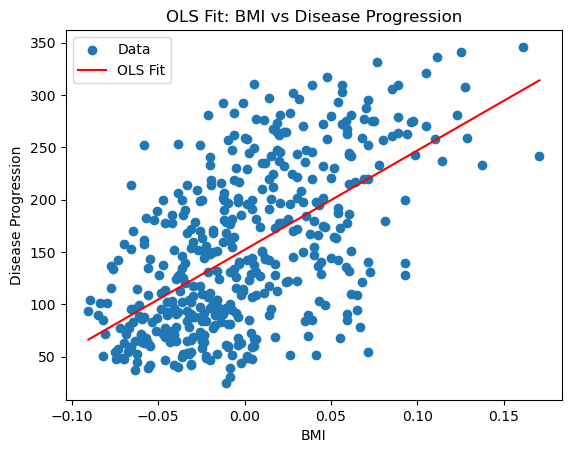

'beta0: 152.13348416289617, beta1: 949.4352603840387'


In [3]:
x = x_bmi.reshape(-1)
y = y.reshape(-1)

x_bar = x.mean()
y_bar = y.mean()

beta1 = ((x - x_bar) * (y - y_bar)).sum() / ((x - x_bar) ** 2).sum()
beta0 = y_bar - beta1 * x_bar

y_hat = beta0 + beta1 * x
residuals = y - y_hat

x_sorted_idx = np.argsort(x)
x_sorted = x[x_sorted_idx]
y_hat_sorted = y_hat[x_sorted_idx]

plt.figure()
plt.scatter(x, y)
plt.plot(x_sorted, y_hat_sorted, color="red")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("OLS Fit: BMI vs Disease Progression")
plt.legend(["Data", "OLS Fit"])
plt.show()

pprint(f"beta0: {beta0}, beta1: {beta1}")


This 2D plot is useful for building intuition, but real-world outcomes rarely depend on only one variable.

The diabetes dataset actually contains 10 standardized features, each describing a different physiological measurement. Instead of studying these variables one at a time, we would like a model that can use all of them together.

Before moving to the full matrix formulation, it helps to look at a few low-dimensional slices of this higher-dimensional space. The next three-dimensional plots show how pairs of features (such as BMI with blood pressure, or BMI with S5) relate jointly to the target.

These plots suggest that disease progression changes along multiple directions in feature space, not just along a single axis.

This observation motivates a natural extension of linear regression: we collect many predictors into a vector and fit them simultaneously using matrix notation.


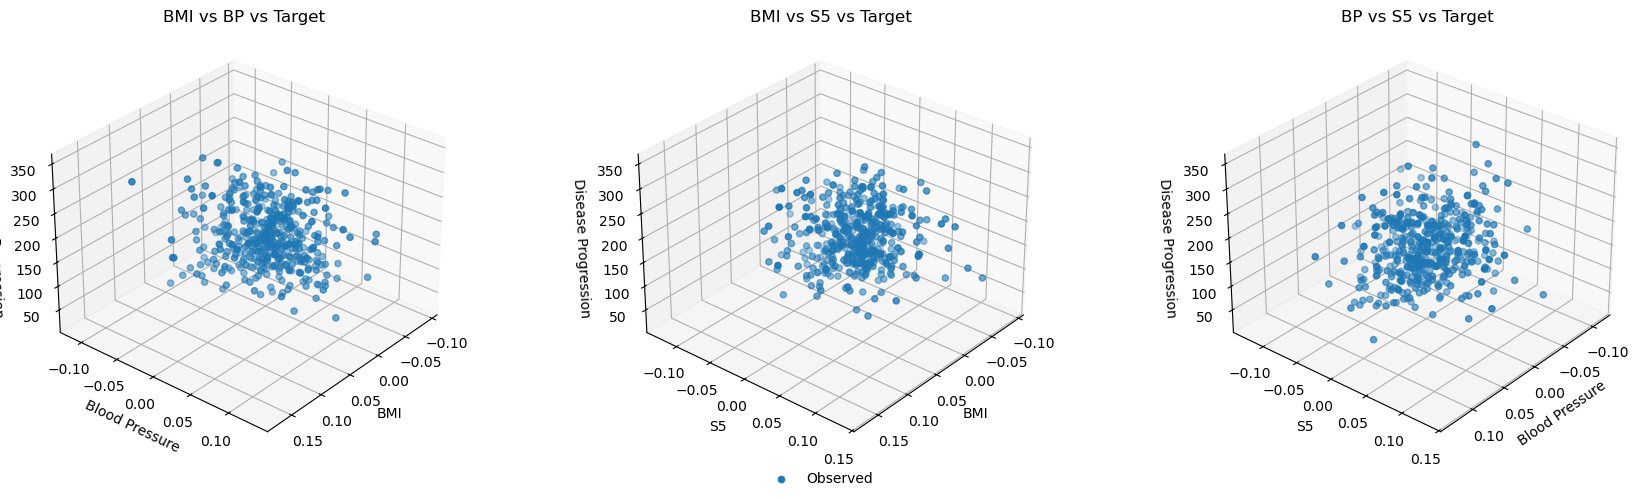

In [4]:
bp_idx = feature_names.index("bp")
s5_idx = feature_names.index("s5")

x_bp = X[:, bp_idx]
x_s5 = X[:, s5_idx]

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131, projection="3d")
ax1.scatter(x_bmi, x_bp, y, label="Observed")
ax1.set_xlabel("BMI")
ax1.set_ylabel("Blood Pressure")
ax1.set_zlabel("Disease Progression")
ax1.set_title("BMI vs BP vs Target")
ax1.view_init(elev=30, azim=40)

ax2 = fig.add_subplot(132, projection="3d")
ax2.scatter(x_bmi, x_s5, y, label="Observed")
ax2.set_xlabel("BMI")
ax2.set_ylabel("S5")
ax2.set_zlabel("Disease Progression")
ax2.set_title("BMI vs S5 vs Target")
ax2.view_init(elev=30, azim=40)

ax3 = fig.add_subplot(133, projection="3d")
ax3.scatter(x_bp, x_s5, y, label="Observed")
ax3.set_xlabel("Blood Pressure")
ax3.set_ylabel("S5")
ax3.set_zlabel("Disease Progression")
ax3.set_title("BP vs S5 vs Target")
ax3.view_init(elev=30, azim=40)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()


## Matrix Form

We now extend the scalar derivation to the case of many predictors.

Let $X$ be the $n \times p$ design matrix whose columns contain the predictors (including a column of ones for the intercept). Let $y$ be the $n \times 1$ vector of observed responses, and let $\beta$ be the $p \times 1$ vector of coefficients. Using matrix notation, the linear model can be written as

$$
y = X\beta + \varepsilon.
$$

The sum of squared errors can be written compactly as

$$
S(\beta) = (y - X\beta)^T (y - X\beta).
$$

Taking the derivative with respect to $\beta$ gives

$$
\nabla_\beta S(\beta) = -2 X^T (y - X\beta).
$$

At the minimum, this gradient must equal zero. This leads to the normal equations

$$
X^T (y - X\hat{\beta}) = 0,
$$

or equivalently,

$$
X^T X \hat{\beta} = X^T y.
$$

If the matrix $X^T X$ is invertible, the solution is

$$
\hat{\beta} = (X^T X)^{-1} X^T y.
$$

Here, $X$ has size $n \times p$, $y$ has size $n \times 1$, and $\beta$ has size $p \times 1$, so $X^T X$ is a $p \times p$ matrix. Invertibility requires that the columns of $X$ be linearly independent—that is, no predictor can be written as a linear combination of the others.


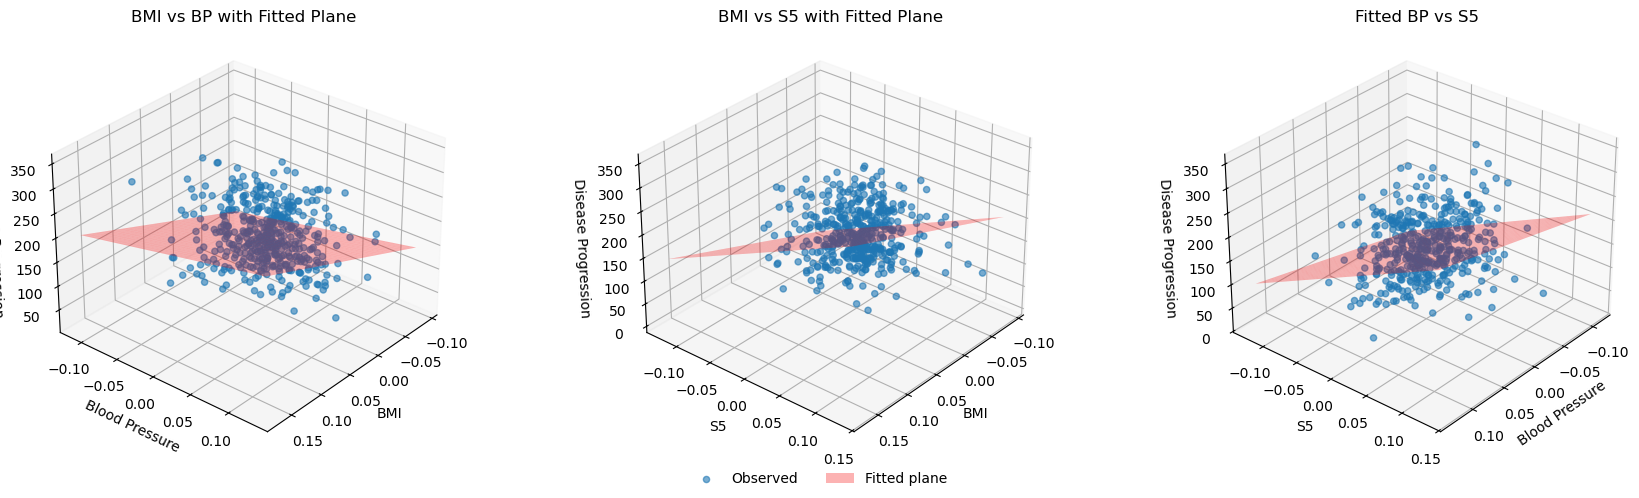

In [5]:
n = X.shape[0]
X_design = np.column_stack((np.ones(n), X))

beta = inv(X_design.T @ X_design) @ X_design.T @ y
X_mean = X.mean(axis=0)


def grid_plane(idx1, idx2, x1_vals, x2_vals):
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    Z = np.full_like(X1, beta[0], dtype=float)
    Z += beta[1 + idx1] * X1
    Z += beta[1 + idx2] * X2
    for j in range(X.shape[1]):
        if j not in (idx1, idx2):
            Z += beta[1 + j] * X_mean[j]
    return X1, X2, Z


x_bmi_grid = np.linspace(x_bmi.min(), x_bmi.max(), 40)
x_bp_grid = np.linspace(x_bp.min(), x_bp.max(), 40)
x_s5_grid = np.linspace(x_s5.min(), x_s5.max(), 40)

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131, projection="3d")
ax1.scatter(x_bmi, x_bp, y, alpha=0.6, label="Observed")
X1, X2, Z = grid_plane(bmi_idx, bp_idx, x_bmi_grid, x_bp_grid)
ax1.plot_surface(X1, X2, Z, alpha=0.3, color="red", edgecolor="none", label="Fitted plane")
ax1.set_xlabel("BMI")
ax1.set_ylabel("Blood Pressure")
ax1.set_zlabel("Disease Progression")
ax1.set_title("BMI vs BP with Fitted Plane")
ax1.view_init(elev=30, azim=40)

ax2 = fig.add_subplot(132, projection="3d")
ax2.scatter(x_bmi, x_s5, y, alpha=0.6, label="Observed")
X1, X2, Z = grid_plane(bmi_idx, s5_idx, x_bmi_grid, x_s5_grid)
ax2.plot_surface(X1, X2, Z, alpha=0.3, color="red", edgecolor="none", label="Fitted plane")
ax2.set_xlabel("BMI")
ax2.set_ylabel("S5")
ax2.set_zlabel("Disease Progression")
ax2.set_title("BMI vs S5 with Fitted Plane")
ax2.view_init(elev=30, azim=40)

ax3 = fig.add_subplot(133, projection="3d")
ax3.scatter(x_bp, x_s5, y, alpha=0.6, label="Observed")
X1, X2, Z = grid_plane(bp_idx, s5_idx, x_bp_grid, x_s5_grid)
ax3.plot_surface(X1, X2, Z, alpha=0.3, color="red", edgecolor="none", label="Fitted plane")
ax3.set_xlabel("Blood Pressure")
ax3.set_ylabel("S5")
ax3.set_zlabel("Disease Progression")
ax3.set_title("Fitted BP vs S5")
ax3.view_init(elev=30, azim=40)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()


# Projection Geometry and the Hat Matrix

So far, we have focused on estimating the coefficients $\hat{\beta}$. We now shift attention from the coefficients to the **predictions themselves**.

From the previous section,

$$
\hat{\beta} = (X^T X)^{-1} X^T y.
$$

Plugging this into the model gives

$$
\hat{y}
= X\hat{\beta}
= X (X^T X)^{-1} X^T y
= Hy,
$$

where

$$
H = X (X^T X)^{-1} X^T.
$$

This shows that fitted values are obtained by multiplying $y$ by a single matrix. Once $H$ is known, predictions are produced directly as $\hat{y} = Hy$, without explicitly computing $\hat{\beta}$. The matrix $H$ reveals what ordinary least squares is doing to the data.

All vectors of the form $X\beta$ lie in the column space of $X$. This space contains every outcome vector that can be produced by a linear model using the given predictors. The observed response $y$ will generally not lie in this space. Ordinary least squares therefore searches for the vector inside $\text{Col}(X)$ that is closest to $y$.

The hat matrix is exactly the operator that performs this search. Multiplying by $H$ projects any vector onto $\text{Col}(X)$. Thus, $\hat{y}$ is not an arbitrary transformation of $y$; it is the best linear approximation to $y$ that can be expressed using the columns of $X$.

This viewpoint explains an important property of residuals. The residual vector

$$
r = y - \hat{y}
$$

is the difference between $y$ and its projection. By basic geometry, this difference must be perpendicular to the subspace onto which we projected. Therefore, $r$ is orthogonal to every column of $X$, which in matrix form becomes

$$
X^T (y - X\hat{\beta}) = 0.
$$

The hat matrix also leads directly to useful diagnostics. Because

$$
\hat{y}_i = \sum_{j=1}^n h_{ij} y_j,
$$

each fitted value is a weighted average of all observed responses. The diagonal element $h_{ii}$ measures how strongly observation $i$ contributes to its own fitted value. Large diagonal entries indicate **high-leverage** points: observations whose predictor values place them in unusual regions of feature space and allow them to strongly influence the fitted model.

The scatter plot below displays the pairs $(y_i, \hat{y}_i)$. Every fitted value shown in the observed-versus-predicted plot is produced by applying the hat matrix to the response vector. It shows how the projection of $y$ onto the column space of $X$ compares to the original data.


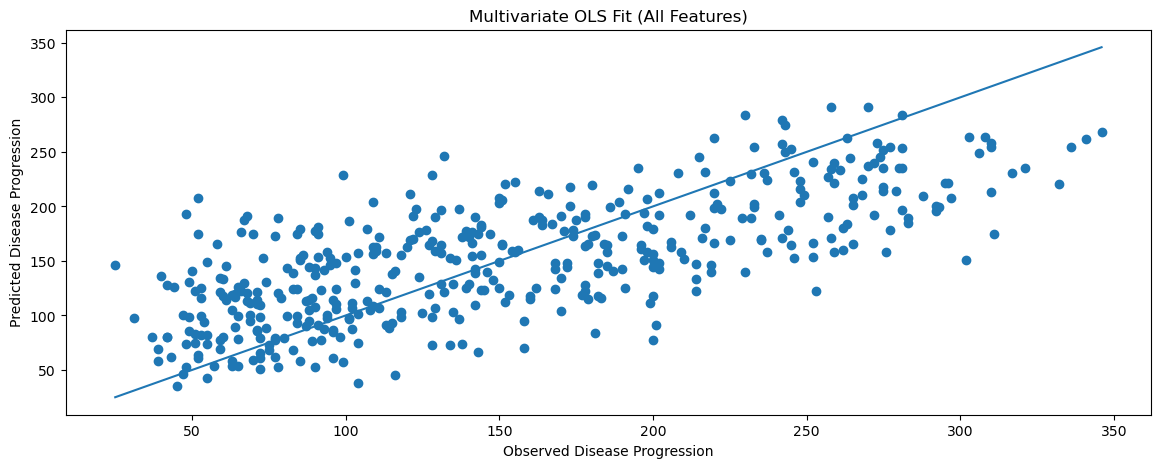

In [6]:
n = X.shape[0]
X_design = np.column_stack((np.ones(n), X))

beta = inv(X_design.T @ X_design) @ X_design.T @ y
# This is algebraically equivalent to the hat matrix.
y_hat = X_design @ beta

fig = plt.figure(figsize=(14, 5))

plt.scatter(y, y_hat)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Observed Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title("Multivariate OLS Fit (All Features)")

plt.show()


Beyond illustrating the projection $Hy$, the observed-versus-predicted plot also provides a first check of how well the model fits the data. There are a few simple things to look for:

- Points near the diagonal: If most points lie close to the line $y_i=\hat{y}_i$, then the model is capturing a large portion of the variation in the response.
- Patterns away from the diagonal: Curvature, clusters, or other visible structure suggest that important nonlinear relationships or interactions may be missing.
- Amount of scatter: A wide vertical spread around the diagonal means large residuals, indicating that much of the response is not well explained by the linear model.
- Extreme points: Observations far from the diagonal have large errors and deserve closer inspection.

This plot gives a quick sense of whether projecting $y$ onto the column space of $X$ is reasonable, but even more, it motivates us dig in for more diagnostics.


## Model Leverage

Inspecting the residuals is not enough, we want to know which observations have the greatest influence on the fitted model. To get this, we look at the structure of the hat matrix. In particular, its diagonal entries,

$$
h_{ii} = H_{ii},
$$

are called **leverage values**.

Recall that fitted values are computed as

$$
\hat{y} = Hy.
$$

This means that each fitted value is formed by combining all observed responses:

$$
\hat{y}_i = h_{i1}y_1 + h_{i2}y_2 + \cdots + h_{in}y_n.
$$

Each row of $H$ tells us how to build one prediction. The special entry is the diagonal term $h_{ii}$, because it multiplies $y_i$ itself. In other words, $h_{ii}$ is the weight placed on an observation’s *own response* when computing its fitted value. If $h_{ii}$ is large, the model must rely heavily on observation $i$ to predict $\hat{y}_i$. If $h_{ii}$ is small, the prediction for point $i$ is mostly determined by other nearby observations.

Leverage therefore measures how strongly an observation supports its own prediction through its predictor values. Points whose feature values lie near the center of the data cloud tend to have small leverage. Points that are far from the bulk of the data in feature space tend to have large leverage. The idea is mainly geometric: leverage depends only on the predictors in $X$, not on the observed response $y_i$. It tells us where a point sits in predictor space, not how large its error is.

In practice, leverage helps identify observations that can strongly influence the fitted model. High-leverage points are not automatically problematic, but they deserve attention because small changes in their responses can noticeably change the fitted hyperplane.

In the following code, we visualize the distribution of leverage values and highlight the observations with the largest leverage in the dataset.


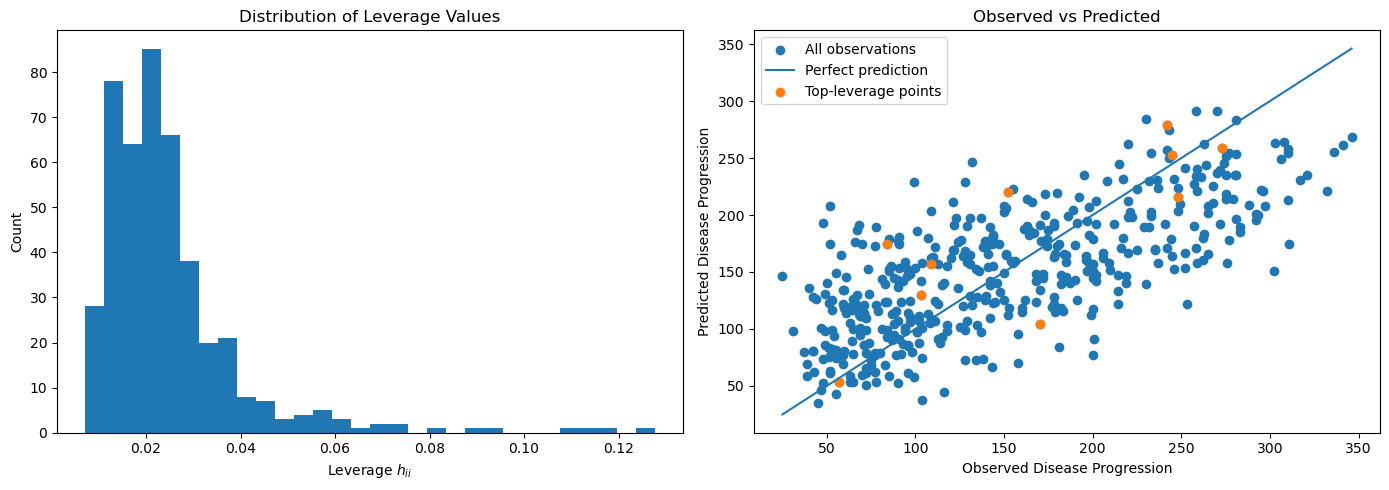

{'top_leverage_indices': [322, 353, 23, 169, 394, 323, 58, 123, 261, 441],
 'top_leverage_values': [0.12761835049800743,
                         0.11795214284713564,
                         0.11172605711177007,
                         0.10794195572718734,
                         0.0941734326935316,
                         0.08792001515233236,
                         0.08156187983243575,
                         0.07195984423241152,
                         0.07181108236173676,
                         0.06910763195689391]}


In [7]:
H = X_design @ inv(X_design.T @ X_design) @ X_design.T
h = np.diag(H)

top_k = 10
top_idx = np.argsort(h)[-top_k:][::-1]

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121)
ax1.hist(h, bins=30)
ax1.set_xlabel("Leverage $h_{ii}$")
ax1.set_ylabel("Count")
ax1.set_title("Distribution of Leverage Values")

ax2 = fig.add_subplot(122)
ax2.scatter(y, y_hat, label="All observations")
ax2.plot([y.min(), y.max()], [y.min(), y.max()], label="Perfect prediction")
ax2.scatter(y[top_idx], y_hat[top_idx], label="Top-leverage points")
ax2.set_xlabel("Observed Disease Progression")
ax2.set_ylabel("Predicted Disease Progression")
ax2.set_title("Observed vs Predicted")
ax2.legend()

plt.tight_layout()
plt.show()

pprint({"top_leverage_indices": top_idx.tolist(), "top_leverage_values": h[top_idx].tolist()})


The left panel shows the distribution of leverage values for all observations. Most points have small leverage, meaning their predictor values lie in common, well-populated regions of feature space. A small number of observations have much larger leverage, forming a long right tail. These correspond to predictor combinations that are relatively unusual.

The right panel shows observed values $y_i$ versus fitted values $\hat{y}_i$, with the diagonal line indicating perfect prediction. The highlighted points are those with the largest leverage.

Two important observations follow. First, high leverage does **not** imply poor prediction: several highlighted points lie close to the diagonal, so they are well fit by the model. Second, leverage reflects *potential influence*, not error size. Because high-leverage points have unusual predictor values, the model relies more heavily on them when determining the fitted hyperplane, even if their residuals are small.

Overall, these plots show that most observations contribute modestly to the fit, while a small number have much greater influence. This motivates additional diagnostics that combine leverage with residual size to identify truly influential observations.

## More Projections with Residuals

Leverage showed us how individual observations influence the fitted values. We now return to the geometry of the hat matrix to understand the structure of the residuals.

Again, the fitted values are given by

$$
\hat{y} = Hy.
$$

The residual vector is the difference between the observed responses and the fitted values:

$$
r = y - \hat{y}.
$$

Substituting for $\hat{y}$ gives

$$
r = y - Hy = (I - H)y,
$$

where $I$ is the $n \times n$ identity matrix.

This expression shows that residuals are produced by applying the matrix $(I - H)$ to the response vector. Just as $H$ projects vectors onto the column space of $X$, the matrix $(I - H)$ projects vectors onto the space perpendicular to the column space of $X$.

Geometrically, ordinary least squares splits the data vector into two perpendicular pieces:

$$
y = Hy + (I - H)y.
$$

The first term, $Hy$, is the part of $y$ that lies in the column space of $X$ and can be explained by a linear combination of the predictors. The second term, $(I - H)y$, is the part of $y$ that lies outside this space and cannot be explained by the linear model.

Because these two components are perpendicular, adjusting the coefficients cannot reduce any part of the residuals. This gives a geometric explanation for

$$
X^T r = 0.
$$

This means that the residuals are perpendicular to every column of $X$.

Viewing residuals through the hat matrix reinforces the central idea of least squares: fitting a linear model is equivalent to projecting the data onto a subspace and keeping only the component that lies within that subspace. The code below visualizes the residuals:

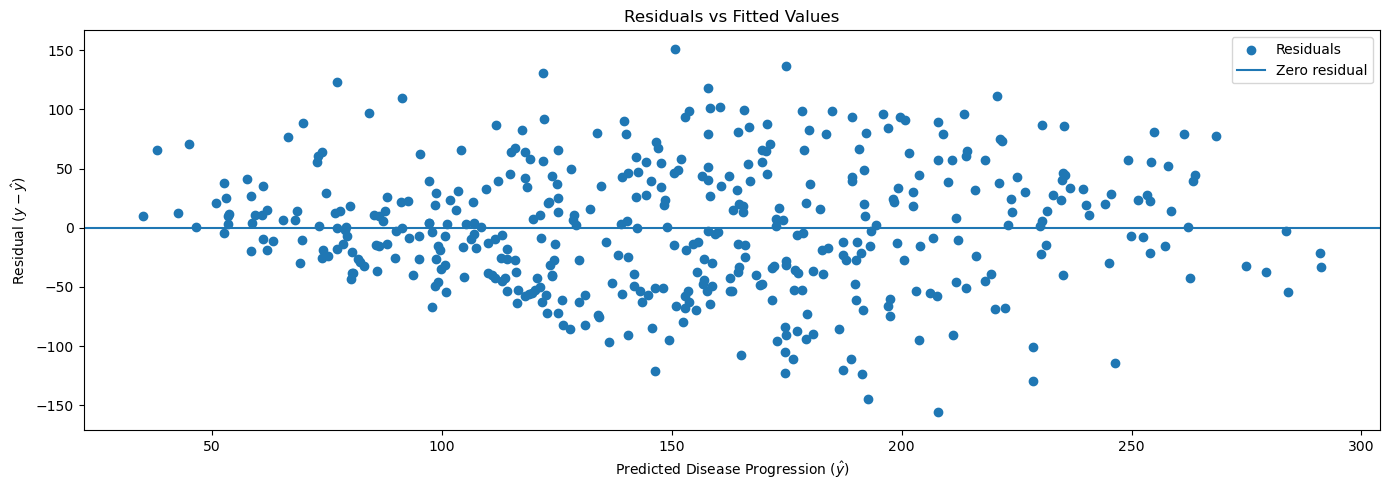

In [8]:
n = X_design.shape[0]
I = np.eye(n)

H = X_design @ np.linalg.inv(X_design.T @ X_design) @ X_design.T

y_hat = H @ y
r_direct = y - y_hat
r_hat = (I - H) @ y

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.scatter(y_hat, r_direct, label="Residuals")
ax1.axhline(0, label="Zero residual")
ax1.set_xlabel("Predicted Disease Progression ($\\hat{y}$)")
ax1.set_ylabel("Residual ($y - \\hat{y}$)")
ax1.set_title("Residuals vs Fitted Values")
ax1.legend()

plt.tight_layout()
plt.show()


This plot shows residuals versus fitted values. Each point represents one observation, and the horizontal line at zero corresponds to perfect prediction. As in simple linear regression, this plot provides a first visual check of whether a linear model is reasonable.

From the projection viewpoint, fitted values $\hat{y}$ are obtained by projecting $y$ onto the column space of $X$, while residuals represent what is left over after this projection. If the linear subspace spanned by the predictors is appropriate, residuals should be scattered around zero with no clear pattern.

The fact that points are centered around the horizontal axis is consistent with the orthogonality condition

$$
X^T r = 0.
$$

Recall that

$$
r = y - \hat{y} = (I - H)y.
$$

This identity holds for any ordinary least squares fit and tells us that residuals come from applying the complementary projection to $y$. In simple terms, residuals capture the part of the data that the linear model cannot explain.

These ideas reflect the geometric decomposition

$$
y = Hy + (I - H)y,
$$

where $Hy$ is the portion explained by the linear model and $(I - H)y$ is the unexplained remainder. Viewing residual plots through this lens connects familiar diagnostics to the projection geometry underlying least squares.


# Model Evaluation

We now know how least squares decomposes the data into an explained part and an unexplained part. This same decomposition can help us measure the model's quality.

Let's look at the geometric identity

$$
y = \hat{y} + r,
$$

where $\hat{y} = Hy$ is the fitted component and $r = y - \hat{y}$ is the residual component. The residual sum of squares (RSS) is therefore

$$
\text{RSS} = \sum_{i=1}^n r_i^2 = \sum_{i=1}^n (y_i - \hat{y}_i)^2,
$$

which measures the total unexplained variation. The total sum of squares (TSS) is

$$
\text{TSS} = \sum_{i=1}^n (y_i - \bar{y})^2,
$$

which measures the total variation in the response around its mean. Because least squares produces an orthogonal decomposition, these quantities satisfy

$$
\text{TSS} = \text{RSS} + \text{ESS},
$$

where

$$
\text{ESS} = \sum_{i=1}^n (\hat{y}_i - \bar{y})^2
$$

is the explained sum of squares. The quality measure known as the coefficient of determination $R^2$ is therefore

$$
R^2 = \frac{\text{ESS}}{\text{TSS}} = 1 - \frac{\text{RSS}}{\text{TSS}}.
$$

$R^2$ represents the fraction of total variation in $y$ that is explained by the linear model. An $R^2$ close to 1 indicates that most of the variation lies in the column space of $X$, while an $R^2$ close to 0 indicates that little variation is explained by the predictors.


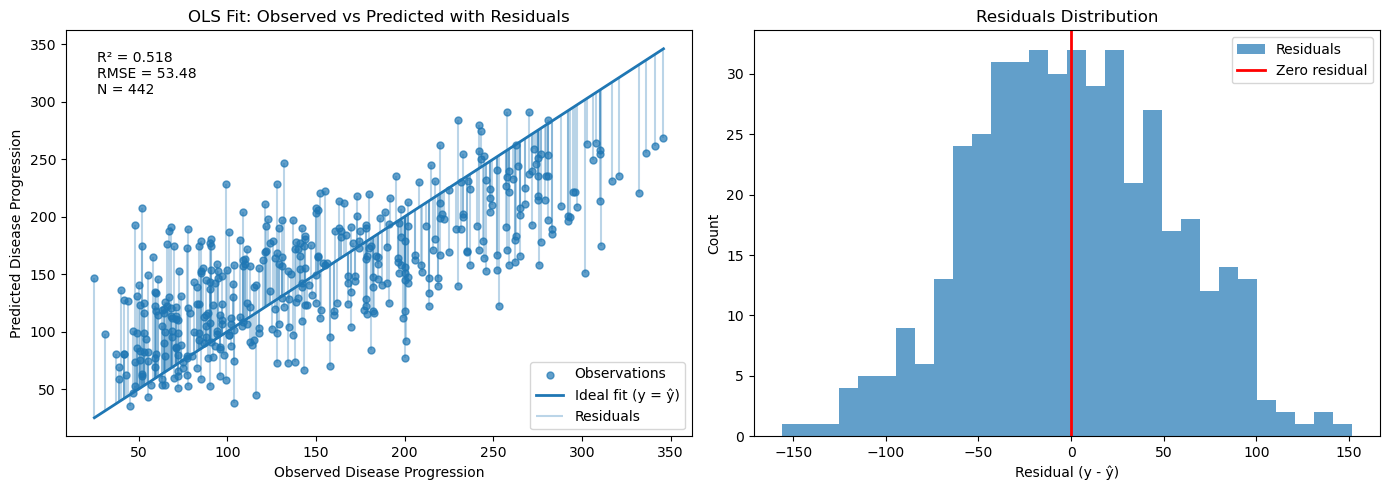

In [9]:
n = X.shape[0]
X_design = np.column_stack((np.ones(n), X))

beta = inv(X_design.T @ X_design) @ X_design.T @ y
y_hat = X_design @ beta

residuals = y - y_hat
ss_res = residuals @ residuals
ss_tot = ((y - y.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
rmse = np.sqrt(ss_res / n)

order = np.argsort(y)
ys = y[order]
yhs = y_hat[order]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 5))

ax0.scatter(y, y_hat, s=25, alpha=0.7, label="Observations")
ax0.plot([y.min(), y.max()], [y.min(), y.max()], linewidth=2, label="Ideal fit (y = ŷ)")
ax0.vlines(y, y_hat, y, alpha=0.3, label="Residuals")
ax0.set_xlabel("Observed Disease Progression")
ax0.set_ylabel("Predicted Disease Progression")
ax0.set_title("OLS Fit: Observed vs Predicted with Residuals")
ax0.text(0.05, 0.95, f"R² = {r2:.3f}\nRMSE = {rmse:.2f}\nN = {n}", transform=ax0.transAxes, verticalalignment="top")
ax0.legend()

ax1.hist(residuals, bins=30, alpha=0.7, label="Residuals")
ax1.axvline(0, linewidth=2, color="red", label="Zero residual")
ax1.set_xlabel("Residual (y - ŷ)")
ax1.set_ylabel("Count")
ax1.set_title("Residuals Distribution")
ax1.legend()

plt.tight_layout()
plt.show()


Here the left panel shows the observed data, the fitted regression line, and the vertical residuals. Each vertical segment represents the difference between an observed value and its prediction. The fitted line captures the overall upward trend in the data, but many points lie far from the line. This is reflected in the relatively modest value of $R^2$, which indicates that only a portion of the total variation in the response is explained by the linear model.

The right panel shows a histogram of the residuals. The distribution is centered near zero, which is consistent with the assumption that errors have mean zero. However, the spread is fairly wide, indicating substantial unexplained variability.

Together, these plots suggest that while the linear model captures some structure in the data, a large amount of variation remains unexplained. This may indicate that important predictors are missing, that nonlinear relationships are present, or that noise in the system is large.


# Assumptions and the Gauss–Markov Theorem

Up to this point, we have focused on geometry: projecting $y$ onto the column space of $X$ to obtain fitted values, and interpreting residuals as what remains after this projection.

To talk about uncertainty and reliability, we now introduce a simple statistical model for how the data are generated:

$$
y = X\beta + \varepsilon,
$$

where $\varepsilon$ represents random noise.

We make three standard assumptions:

- The errors have mean zero: $E[\varepsilon \mid X] = 0$.  
- The errors have constant variance and are uncorrelated: $\mathrm{Var}(\varepsilon \mid X) = \sigma^2 I$.  
- The columns of $X$ are linearly independent.

These assumptions allow us to connect the geometric solution to statistical guarantees.

Under these conditions, the Gauss–Markov theorem states that ordinary least squares has a special optimality property: among all estimators that are linear functions of $y$ and unbiased, the OLS estimator has the smallest variance.

In short, OLS is the best linear unbiased estimator (BLUE) of $\beta$.



## Sampling Variability of the Coefficients

Even though the estimator has the same formula as before,

$$
\hat{\beta} = (X^T X)^{-1} X^T y,
$$

it is now a random vector, because it depends on the random noise $\varepsilon$.

Substituting the model into the estimator gives

$$
\hat{\beta}
= (X^T X)^{-1} X^T (X\beta + \varepsilon)
= \beta + (X^T X)^{-1} X^T \varepsilon.
$$

Taking expectations,

$$
\mathbb{E}[\hat{\beta}] = \beta,
$$

so OLS is unbiased.

The covariance matrix of $\hat{\beta}$ is

$$
\mathrm{Cov}(\hat{\beta}) = \sigma^2 (X^T X)^{-1}.
$$

The variance of a single coefficient is the corresponding diagonal entry:

$$
\mathrm{Var}(\hat{\beta}_j)
= \sigma^2 \big[(X^T X)^{-1}\big]_{jj}.
$$

This shows that coefficient uncertainty is controlled by the inverse of $X^T X$. When predictors are highly correlated, $X^T X$ becomes nearly singular, and the variances of the coefficient estimates become large.

In practice, $\sigma^2$ is unknown and is estimated from the residuals,

$$
\hat{\sigma}^2 = \frac{1}{n-p} \sum_{i=1}^n r_i^2,
$$

where $n$ is the number of observations and $p$ is the number of coefficients.

The **standard error** of $\hat{\beta}_j$ is then

$$
\mathrm{SE}(\hat{\beta}_j)
= \sqrt{\hat{\sigma}^2 \big[(X^T X)^{-1}\big]_{jj}}.
$$

If we further assume the noise is Gaussian,

$$
\varepsilon \sim \mathcal{N}(0, \sigma^2 I),
$$

then

$$
\hat{\beta} \sim \mathcal{N}\!\left(\beta,\; \sigma^2 (X^T X)^{-1}\right).
$$

This implies that the standardized quantity

$$
t_j = \frac{\hat{\beta}_j - \beta_j}{\mathrm{SE}(\hat{\beta}_j)}
$$

follows a $t$ distribution with $n-p$ degrees of freedom.

A $100(1-\alpha)\%$ confidence interval for $\beta_j$ is therefore

$$
\hat{\beta}_j \;\pm\; t_{\alpha/2,\,n-p}\,\mathrm{SE}(\hat{\beta}_j).
$$

Large absolute values of $t_j$ indicate strong evidence that the corresponding coefficient differs from zero, while wide confidence intervals indicate high uncertainty.


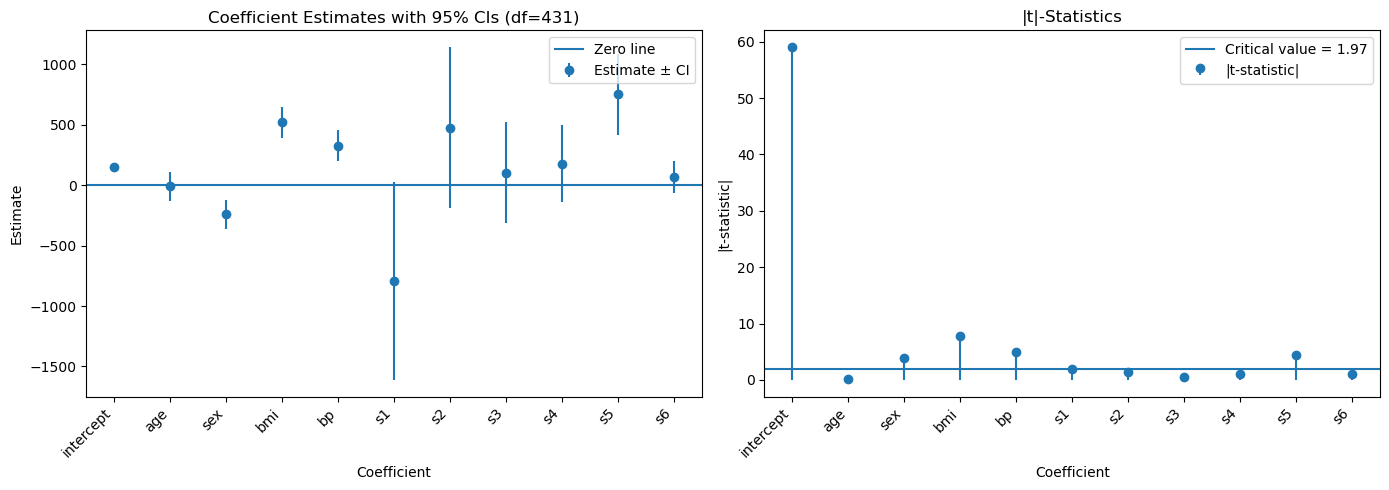

In [10]:
from scipy.stats import t as student_t

n = X.shape[0]
p = X.shape[1] + 1
X_design = np.column_stack((np.ones(n), X))

beta_hat = inv(X_design.T @ X_design) @ X_design.T @ y
y_hat = X_design @ beta_hat
residuals = y - y_hat

sigma2_hat = (residuals @ residuals) / (n - p)

XtX_inv = inv(X_design.T @ X_design)
cov_beta_hat = sigma2_hat * XtX_inv
se_beta_hat = np.sqrt(np.diag(cov_beta_hat))

t_stats = beta_hat / se_beta_hat
dfree = n - p

p_vals = 2 * (1 - student_t.cdf(np.abs(t_stats), df=dfree))

alpha = 0.05
tcrit = student_t.ppf(1 - alpha / 2, df=dfree)
ci_lo = beta_hat - tcrit * se_beta_hat
ci_hi = beta_hat + tcrit * se_beta_hat

terms = ["intercept"] + feature_names

df = pd.DataFrame(
    {
        "term": terms,
        "beta_hat": beta_hat,
        "se": se_beta_hat,
        "t": t_stats,
        "p_value": p_vals,
        f"ci_{int((1 - alpha) * 100)}_lo": ci_lo,
        f"ci_{int((1 - alpha) * 100)}_hi": ci_hi,
    }
).sort_values("p_value")

x_pos = np.arange(len(terms))

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121)
ax1.errorbar(x_pos, beta_hat, yerr=tcrit * se_beta_hat, fmt="o", label="Estimate ± CI")
ax1.axhline(0, label="Zero line")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(terms, rotation=45, ha="right")
ax1.set_xlabel("Coefficient")
ax1.set_ylabel("Estimate")
ax1.set_title(f"Coefficient Estimates with {int((1 - alpha) * 100)}% CIs (df={dfree})")
ax1.legend()

ax2 = fig.add_subplot(122)
ax2.stem(x_pos, np.abs(t_stats), basefmt=" ", label="|t-statistic|")
ax2.axhline(tcrit, label=f"Critical value = {tcrit:.2f}")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(terms, rotation=45, ha="right")
ax2.set_xlabel("Coefficient")
ax2.set_ylabel("|t-statistic|")
ax2.set_title("|t|-Statistics")
ax2.legend()

plt.tight_layout()
plt.show()


The left panel shows the estimated coefficients together with their uncertainty. Each point is a coefficient estimate $\hat{\beta}_j$, and the vertical bars represent its uncertainty based on sampling variability. The horizontal line at zero corresponds to no linear effect.

Short error bars indicate that a coefficient is estimated precisely. Long error bars indicate substantial uncertainty. In other words, some coefficients are tightly pinned down by the data, while others are not.

When an error bar lies entirely on one side of zero, the data provide fairly strong evidence that the corresponding predictor has a nonzero linear association with the response, after accounting for the other predictors. When an error bar overlaps zero, the data are consistent with a wide range of possible values, including no effect at all. In this case, the sign and magnitude of the coefficient should be interpreted cautiously.

In this example, the coefficients for **age**, **S2**, **S3**, **S4**, and **S6** all have error bars that cross zero. This suggests that, after accounting for the other predictors, their individual linear effects are difficult to distinguish from noise.

The right panel shows the same information using absolute $t$-statistics. Each $t$-statistic compares the size of an estimated effect to its typical sampling fluctuation. Under the Gaussian noise assumption, these statistics follow a $t$ distribution with $n-p$ degrees of freedom (here, $n-p = 431$). The horizontal line marks the corresponding critical value for a 5% significance level. Coefficients whose $|t|$ values fall below this line do not provide strong evidence against a zero effect.

Together, the two panels convey the same message: several predictors appear weak or uninformative once the others are included, while a smaller subset shows strong and stable associations with the response.


# Fixing Poorly Determined Coefficients

Coefficient diagnostics highlight predictors whose estimated effects are highly uncertain. Such coefficients are not necessarily wrong, but they are unreliable for interpretation. When this occurs, several practical responses are common.

1. Accept prediction-focused modeling.  
If the primary goal is prediction rather than interpretation, unstable individual coefficients may be acceptable as long as the fitted values perform well. In this case, emphasis is placed on predictive accuracy rather than on attributing effects to specific variables.

2. Reduce collinearity through feature selection or transformation.  
Highly correlated predictors tend to produce large standard errors. Removing redundant variables, combining related predictors, or applying dimension-reduction techniques such as principal components can improve coefficient stability.

3. Apply regularization (ridge).  
Penalized regression modifies the least-squares objective by adding a penalty on coefficient size:

$$
\min_\beta \|y - X\beta\|^2 + \lambda \|\beta\|^2.
$$

This yields the closed-form solution

$$
\hat{\beta}_{\text{ridge}} = (X^T X + \lambda I)^{-1} X^T y.
$$

The penalty shrinks coefficients toward zero, reducing variance at the cost of introducing bias. This bias–variance tradeoff often leads to more stable and useful estimates.

4. Use sparsity-inducing penalties (lasso).  
The lasso replaces the $\ell_2$ penalty with an $\ell_1$ penalty,

$$
\min_\beta \|y - X\beta\|^2 + \lambda \|\beta\|_1.
$$

Unlike ridge, the lasso has no closed-form solution and must be computed numerically. It encourages exact zeros in the coefficients, producing simpler models by automatically performing feature selection. For this section, we use the scikit-learn implementation.

The code below illustrates how penalization affects the coefficient estimates.


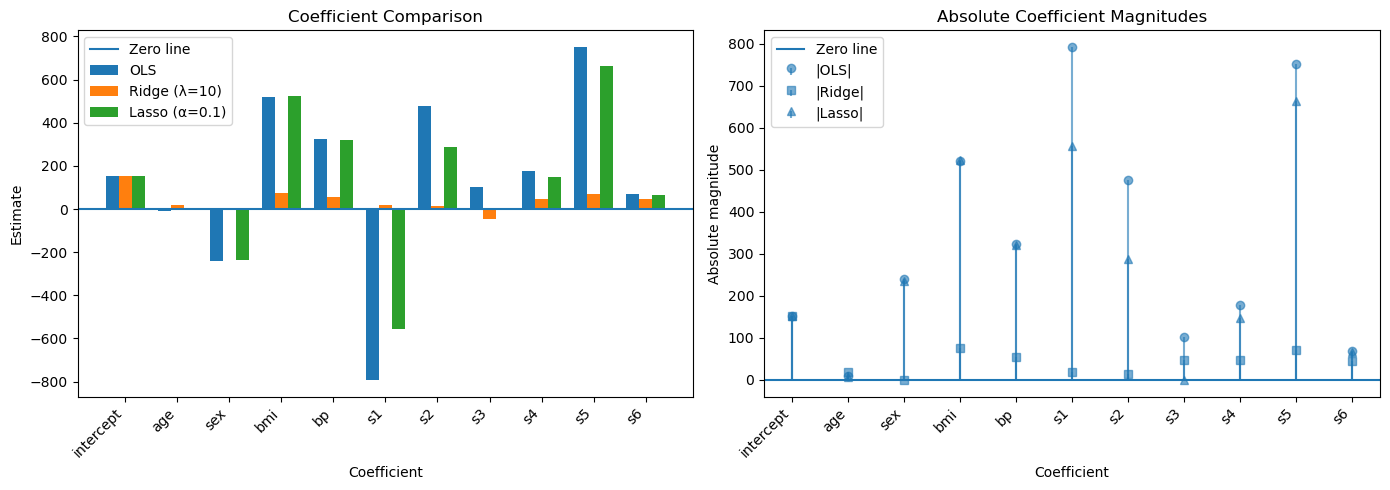

Number of exact zeros in Lasso (excluding intercept): 1 / 10


In [11]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

n = X.shape[0]
X_design = np.column_stack((np.ones(n), X))

beta_ols = inv(X_design.T @ X_design) @ X_design.T @ y

lam_ridge = 10.0
lam_lasso = 0.1

I_p = np.eye(X_design.shape[1])
I_p[0, 0] = 0.0
beta_ridge = inv(X_design.T @ X_design + lam_ridge * I_p) @ X_design.T @ y

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

lasso = Lasso(alpha=lam_lasso, fit_intercept=True, max_iter=100000)
lasso.fit(X_std, y)
beta_lasso_std = np.r_[lasso.intercept_, lasso.coef_]

beta_lasso = beta_lasso_std.copy()
beta_lasso[1:] = beta_lasso_std[1:] / scaler.scale_

terms = ["intercept"] + feature_names
df = pd.DataFrame({"term": terms, "OLS": beta_ols, "Ridge": beta_ridge, "Lasso": beta_lasso})

df["Lasso_is_zero"] = np.isclose(df["Lasso"], 0.0, atol=1e-10)
df["Ridge/OLS"] = df["Ridge"] / df["OLS"]
df["Lasso/OLS"] = df["Lasso"] / df["OLS"]


idx = np.arange(len(terms))
width = 0.25

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121)
ax1.bar(idx - width, beta_ols, width, label="OLS")
ax1.bar(idx, beta_ridge, width, label=f"Ridge (λ={lam_ridge:g})")
ax1.bar(idx + width, beta_lasso, width, label=f"Lasso (α={lam_lasso:g})")
ax1.axhline(0, label="Zero line")
ax1.set_xticks(idx)
ax1.set_xticklabels(terms, rotation=45, ha="right")
ax1.set_xlabel("Coefficient")
ax1.set_ylabel("Estimate")
ax1.set_title("Coefficient Comparison")
ax1.legend()

ax2 = fig.add_subplot(122)
stem_ols = ax2.stem(idx, np.abs(beta_ols), markerfmt="o", basefmt=" ", label="|OLS|")
stem_ridge = ax2.stem(idx, np.abs(beta_ridge), markerfmt="s", basefmt=" ", label="|Ridge|")
stem_lasso = ax2.stem(idx, np.abs(beta_lasso), markerfmt="^", basefmt=" ", label="|Lasso|")

for stem in (stem_ols, stem_ridge, stem_lasso):
    stem.markerline.set_alpha(0.6)
    stem.stemlines.set_alpha(0.6)

ax2.axhline(0, label="Zero line")
ax2.set_xticks(idx)
ax2.set_xticklabels(terms, rotation=45, ha="right")
ax2.set_xlabel("Coefficient")
ax2.set_ylabel("Absolute magnitude")
ax2.set_title("Absolute Coefficient Magnitudes")
ax2.legend()

plt.tight_layout()
plt.show()

print(
    f"Number of exact zeros in Lasso (excluding intercept): {np.sum(np.isclose(beta_lasso[1:], 0.0, atol=1e-10))} / {len(beta_lasso) - 1}"
)


The left panel compares coefficient estimates produced by ordinary least squares, ridge regression, and the lasso. The OLS estimates show large magnitudes for several predictors, reflecting the instability caused by correlated features. Ridge regression shrinks all coefficients toward zero, producing much smaller and more balanced estimates. The lasso also shrinks coefficients, but in a different way: some coefficients are driven very close to zero, while others remain relatively large.

This behavior reflects the different penalties used by the two methods. Ridge applies a quadratic penalty that discourages large coefficients but keeps all predictors in the model. The lasso applies an absolute-value penalty that encourages sparsity, effectively performing variable selection.

The right panel shows the absolute magnitudes of the coefficients for each method.

# Conclusion

This article developed linear regression from first principles, beginning with the scalar least squares problem and progressing to the full multivariable matrix formulation. Throughout, we emphasized a unifying geometric perspective: ordinary least squares is fundamentally a projection of the response vector onto the column space of the design matrix.

Viewing regression through this lens clarifies many core results. The normal equations arise from orthogonality of residuals to the model space. The hat matrix is the linear operator that performs the projection. Residuals appear naturally as the complementary projection onto the orthogonal subspace. Diagnostics such as leverage and residual plots follow directly from this same structure.

We then moved from geometry to statistical uncertainty, showing how randomness in the data leads to variability in the estimated coefficients. This helps explain why prediction can be reliable even when individual coefficients are difficult to interpret. Regularization methods such as ridge regression and the lasso address this issue by stabilizing estimation, trading a small amount of bias for large reductions in variance.

For clarity, many technical details and theoretical refinements were intentionally simplified or omitted in this article. A more rigorous and complete treatment, including deeper discussions of assumptions, matrix calculus, and asymptotic theory, is provided in the accompanying PDF.

Thus we learned that linear regression is a coherent framework combining linear algebra, geometry, and probability. This perspective forms the foundation for many modern extensions, including generalized linear models, Bayesian regression, and simulation-based inference, all of which build on the same underlying principles.

See you next time!


# References

- A Rigorous Introduction to Linear Models: [PDF](https://github.com/adamd1985/quant_research/blob/main/papers/A%20Rigorous%20Introduction%20to%20Linear%20Models.pdf)


## Github

Article here is also available on [Github](https://github.com/adamd1985/quant_research/blob/main/deep_linear_regression.ipynb)

Kaggle notebook available [here](https://www.kaggle.com/code/addarm/solving-the-efficient-frontier-in-stocks)


## Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.

## CC Licensing and Use

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.